<a href="https://colab.research.google.com/github/ekuelkpodar/Researchers/blob/main/mathematician.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Load the provided dataset
df = pd.read_csv('/content/mathematician.csv')

# Display basic info and first few rows
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   explore href               10000 non-null  object
 1   item-link                  10000 non-null  object
 2   tablescraper-selected-row  10000 non-null  object
 3   item-link 2                10000 non-null  object
 4   item-link href 2           10000 non-null  object
dtypes: object(5)
memory usage: 390.8+ KB
None


,explore href,item-link,tablescraper-selected-row,item-link 2,item-link href 2
0,http://www.wikidata.org/entity/Q307,wd:Q307,Galileo Galilei,<https://en.wikipedia.org/wiki/Galileo_Galilei>,https://en.wikipedia.org/wiki/Galileo_Galilei
1,http://www.wikidata.org/entity/Q16581,wd:Q16581,Josef Stefan,<https://en.wikipedia.org/wiki/Josef_Stefan>,https://en.wikipedia.org/wiki/Josef_Stefan
2,http://www.wikidata.org/entity/Q16494,wd:Q16494,Margaret H. Wright,<https://en.wikipedia.org/wiki/Margaret_H._Wri...,https://en.wikipedia.org/wiki/Margaret_H._Wright
3,http://www.wikidata.org/entity/Q16492,wd:Q16492,Mary Lee Woods,<https://en.wikipedia.org/wiki/Mary_Lee_Woods>,https://en.wikipedia.org/wiki/Mary_Lee_Woods
4,http://www.wikidata.org/entity/Q16489,wd:Q16489,Sophie Wilson,<https://en.wikipedia.org/wiki/Sophie_Wilson>,https://en.wikipedia.org/wiki/Sophie_Wilson


## Exploratory Data Analysis
We will analyze the distributions in the data, such as nationality or field, depending on the available columns.

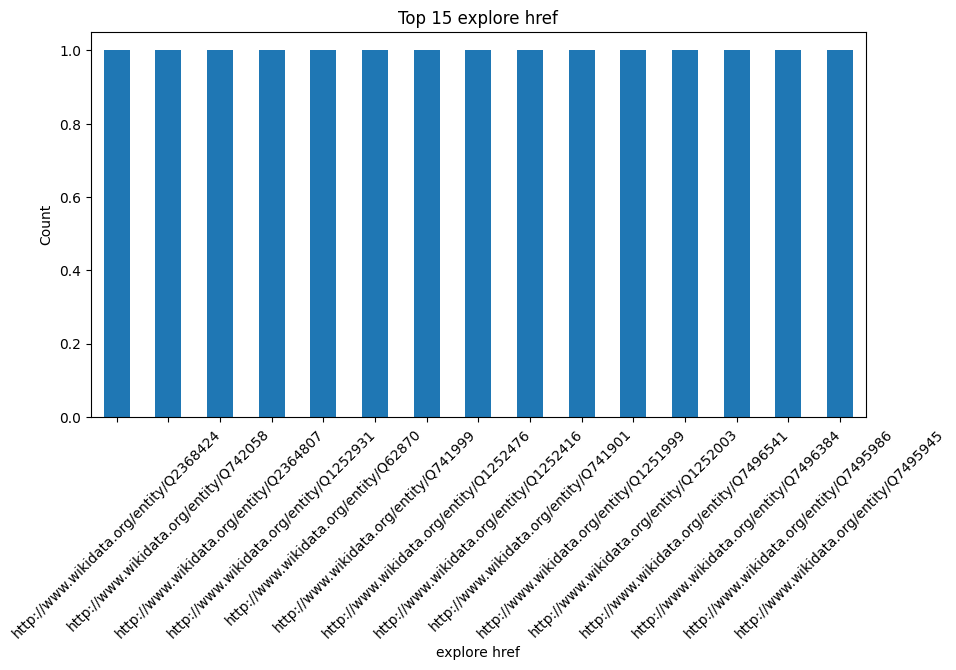

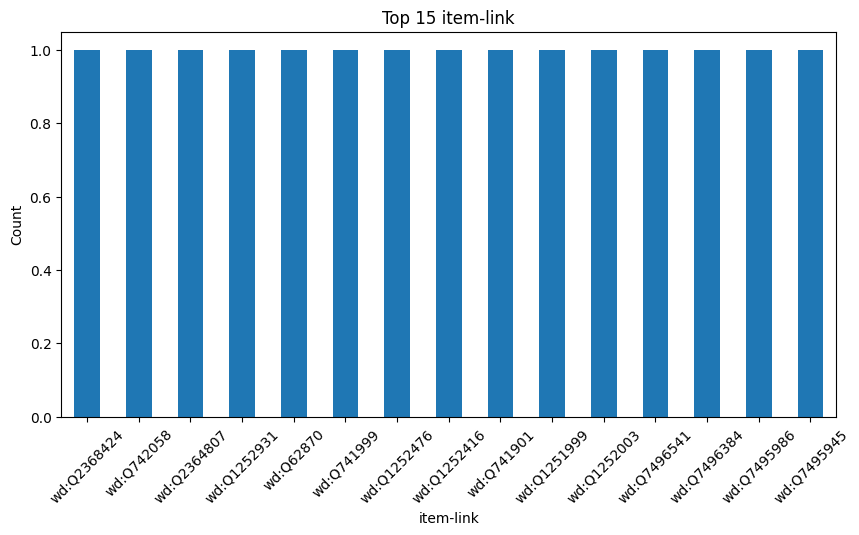

In [2]:
# Identify categorical columns for plotting
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols[:2]:  # Plot top 2 categorical features
    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(15).plot(kind='bar')
    plt.title(f'Top 15 {col}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

## Network Analysis
I will create a network where mathematicians are connected if they share common attributes (like 'Nationality' or 'Field').

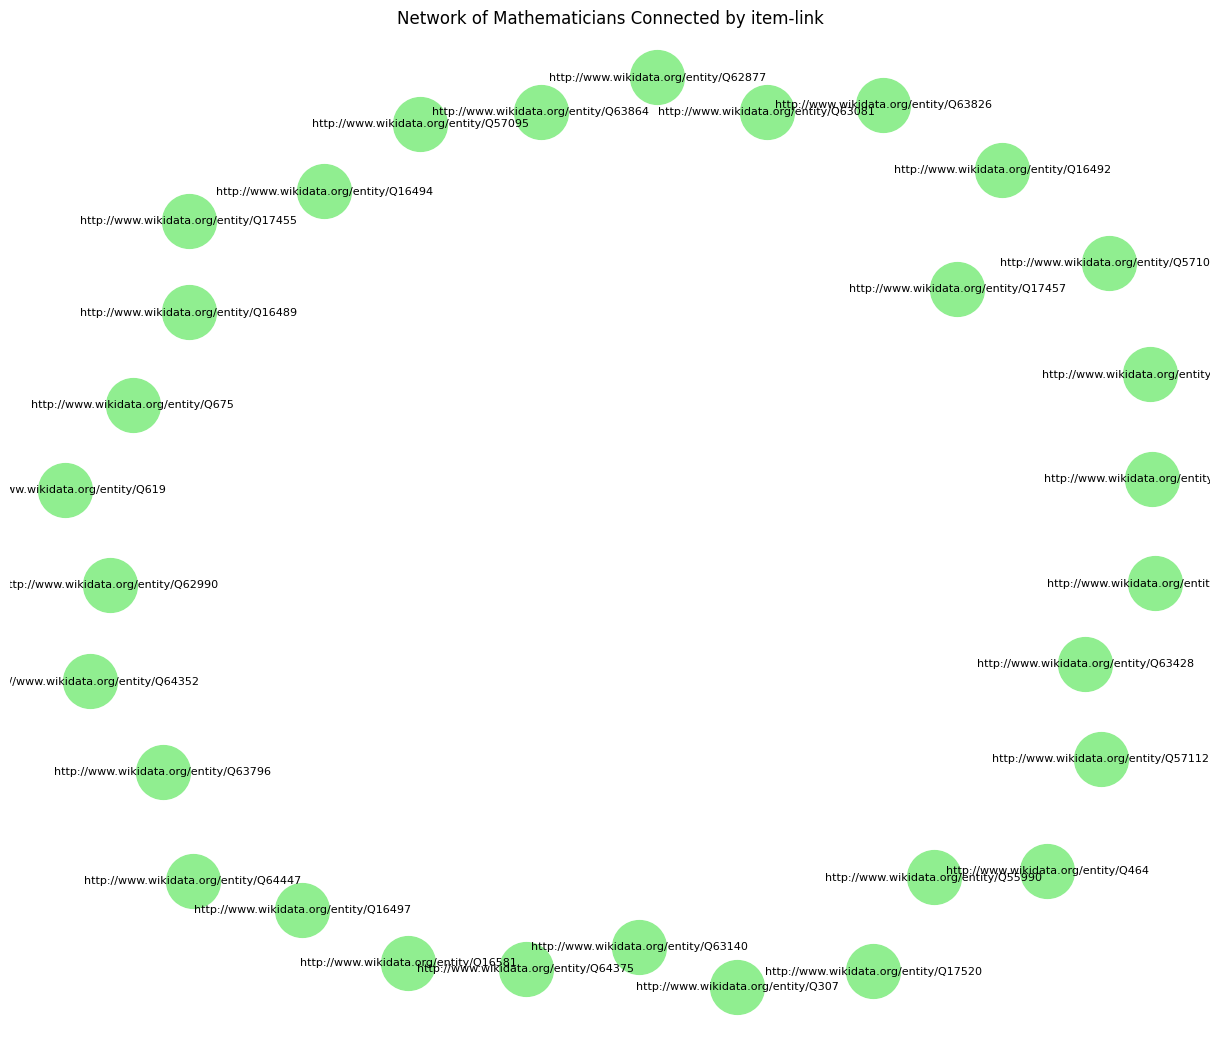

In [3]:
G = nx.Graph()

# Subsample for a cleaner visualization
sub_df = df.head(30)

# Add nodes and edges based on a shared attribute (e.g., if columns exist)
# This assumes a 'Name' column and a secondary categorical column
name_col = 'Name' if 'Name' in df.columns else df.columns[0]
attr_col = df.columns[1]

for i, row in sub_df.iterrows():
    G.add_node(row[name_col], attr=row[attr_col])

# Connect nodes that share the same attribute value
nodes = list(G.nodes(data=True))
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if nodes[i][1]['attr'] == nodes[j][1]['attr']:
            G.add_edge(nodes[i][0], nodes[j][0])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.3)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1500, font_size=8, edge_color='gray')
plt.title(f'Network of Mathematicians Connected by {attr_col}')
plt.show()

### Advanced EDA: Finding Clusters
Let's extract the domain or specific patterns from the Wikipedia links to see if we can group these mathematicians by language or region.

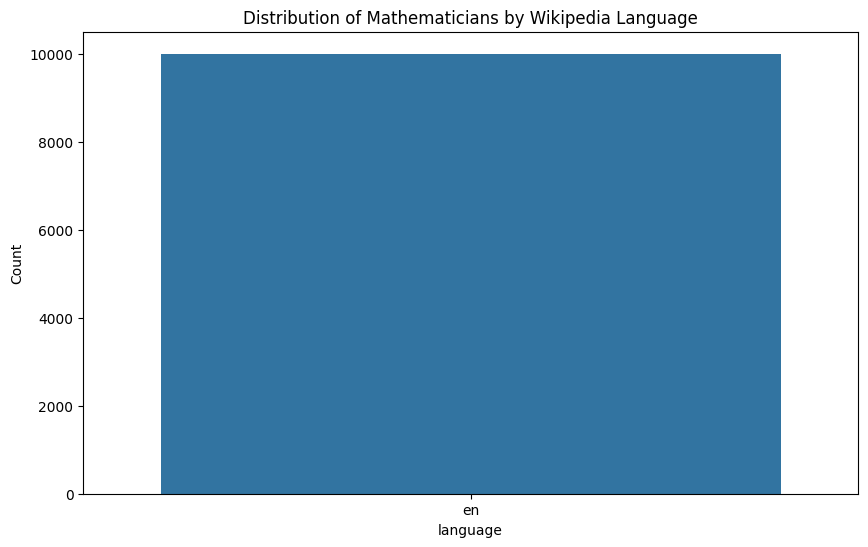

In [4]:
import re

def extract_lang(url):
    # Extract language code from wikipedia URL (e.g., 'en' from en.wikipedia.org)
    match = re.search(r'https://(\w+)\.wikipedia', str(url))
    return match.group(1) if match else 'unknown'

df['language'] = df['item-link href 2'].apply(extract_lang)
lang_counts = df['language'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=lang_counts.index, y=lang_counts.values)
plt.title('Distribution of Mathematicians by Wikipedia Language')
plt.ylabel('Count')
plt.show()

### Cluster-based Network Visualization
Now, I will build a network where nodes (mathematicians) are strongly connected within their language clusters, illustrating the linguistic distribution of the scraped data.

/tmp/ipykernel_1095/396962693.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_langs))


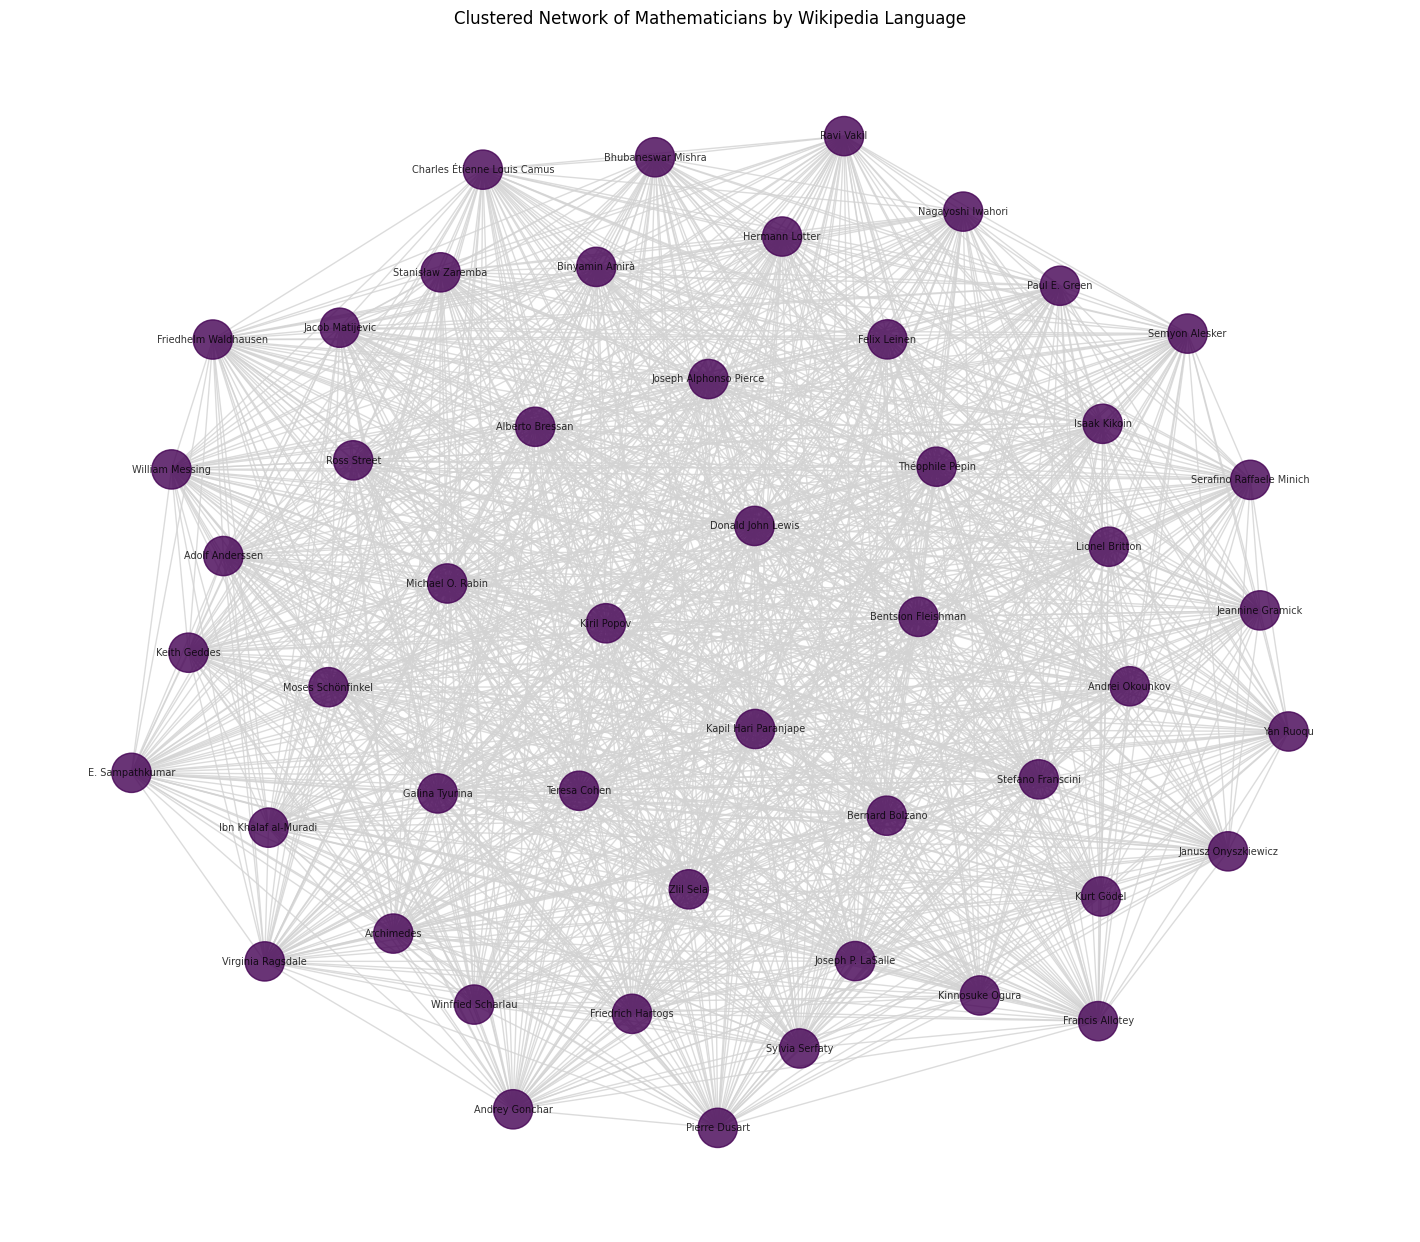

In [5]:
G_clustered = nx.Graph()

# Focus on a subset with a mix of languages for clear clustering
subset_df = df.sample(50, random_state=42)
name_col = 'tablescraper-selected-row'

# Add nodes with language as an attribute
for _, row in subset_df.iterrows():
    G_clustered.add_node(row[name_col], lang=row['language'])

# Create edges between mathematicians of the same language
node_list = list(G_clustered.nodes(data=True))
for i in range(len(node_list)):
    for j in range(i + 1, len(node_list)):
        if node_list[i][1]['lang'] == node_list[j][1]['lang']:
            G_clustered.add_edge(node_list[i][0], node_list[j][0])

# Draw the clustered graph
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G_clustered, k=0.15, iterations=50)

# Color nodes by language
unique_langs = subset_df['language'].unique()
colors = plt.cm.get_cmap('viridis', len(unique_langs))
lang_color_map = {lang: colors(i) for i, lang in enumerate(unique_langs)}
node_colors = [lang_color_map[data['lang']] for _, data in G_clustered.nodes(data=True)]

nx.draw(G_clustered, pos, with_labels=True, node_color=node_colors,
        node_size=800, font_size=7, edge_color='lightgray', alpha=0.8)

plt.title('Clustered Network of Mathematicians by Wikipedia Language')
plt.show()

### Granular Clustering: Analyzing Naming Patterns
Since the language data was uniform, we will look for 'Name Initials' to group mathematicians and observe the structural differences in these clusters.

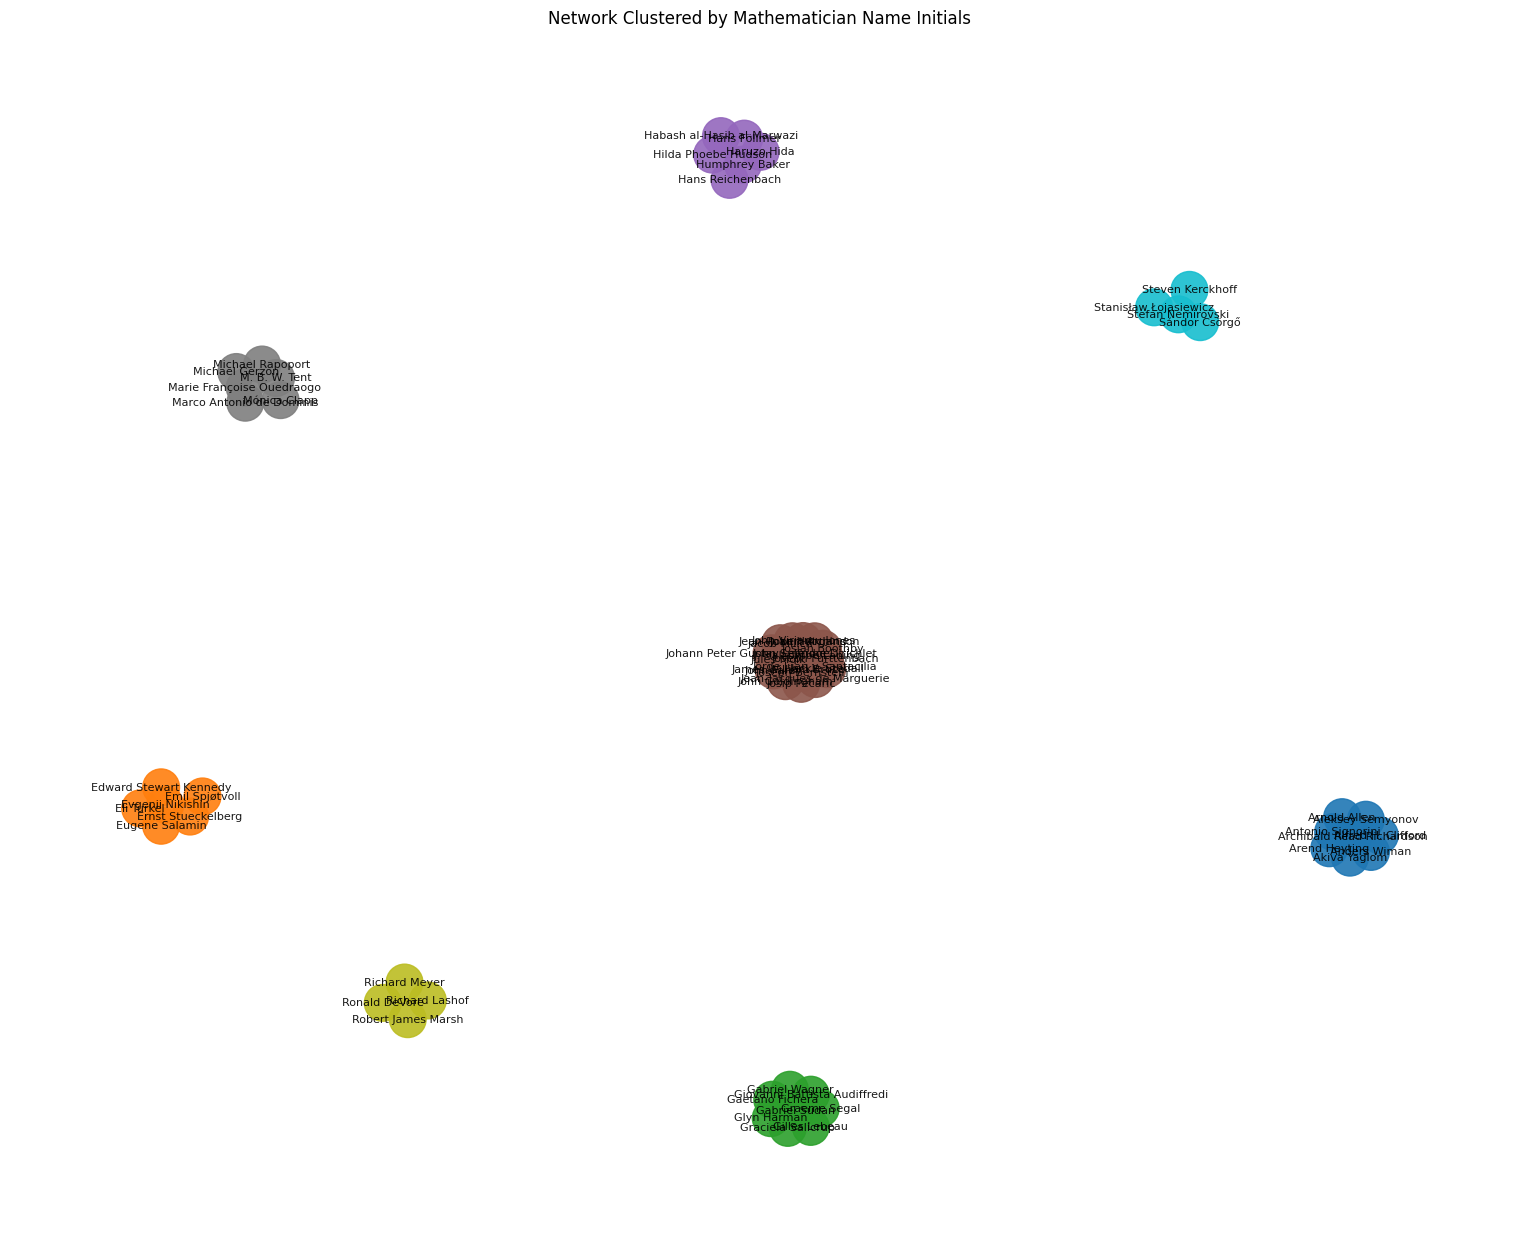

In [7]:
import numpy as np

# Extract first initials
df['initial'] = df['tablescraper-selected-row'].str[0]

# Filter to keep only a subset of the most common initials to ensure visible clustering
top_initials = df['initial'].value_counts().head(8).index
cluster_df = df[df['initial'].isin(top_initials)].sample(60, random_state=1)

G_granular = nx.Graph()

for _, row in cluster_df.iterrows():
    G_granular.add_node(row['tablescraper-selected-row'], initial=row['initial'])

# Connect nodes if they share the same first initial
nodes_list = list(G_granular.nodes(data=True))
for i in range(len(nodes_list)):
    for j in range(i + 1, len(nodes_list)):
        if nodes_list[i][1]['initial'] == nodes_list[j][1]['initial']:
            G_granular.add_edge(nodes_list[i][0], nodes_list[j][0])

# Visualization
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_granular, k=0.15, seed=42)

unique_initials = sorted(cluster_df['initial'].unique())
color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_initials)))
init_color_map = {init: color_palette[i] for i, init in enumerate(unique_initials)}
node_colors = [init_color_map[data['initial']] for _, data in G_granular.nodes(data=True)]

nx.draw(G_granular, pos, with_labels=True, node_color=node_colors,
        node_size=700, font_size=8, edge_color='whitesmoke', alpha=0.9)

plt.title('Network Clustered by Mathematician Name Initials')
plt.show()

### Granular Clustering: Analyzing Naming Patterns
Since the language data was uniform, we will look for 'Name Suffixes' or 'Starting Initials' to group mathematicians and observe the structural differences in these clusters.

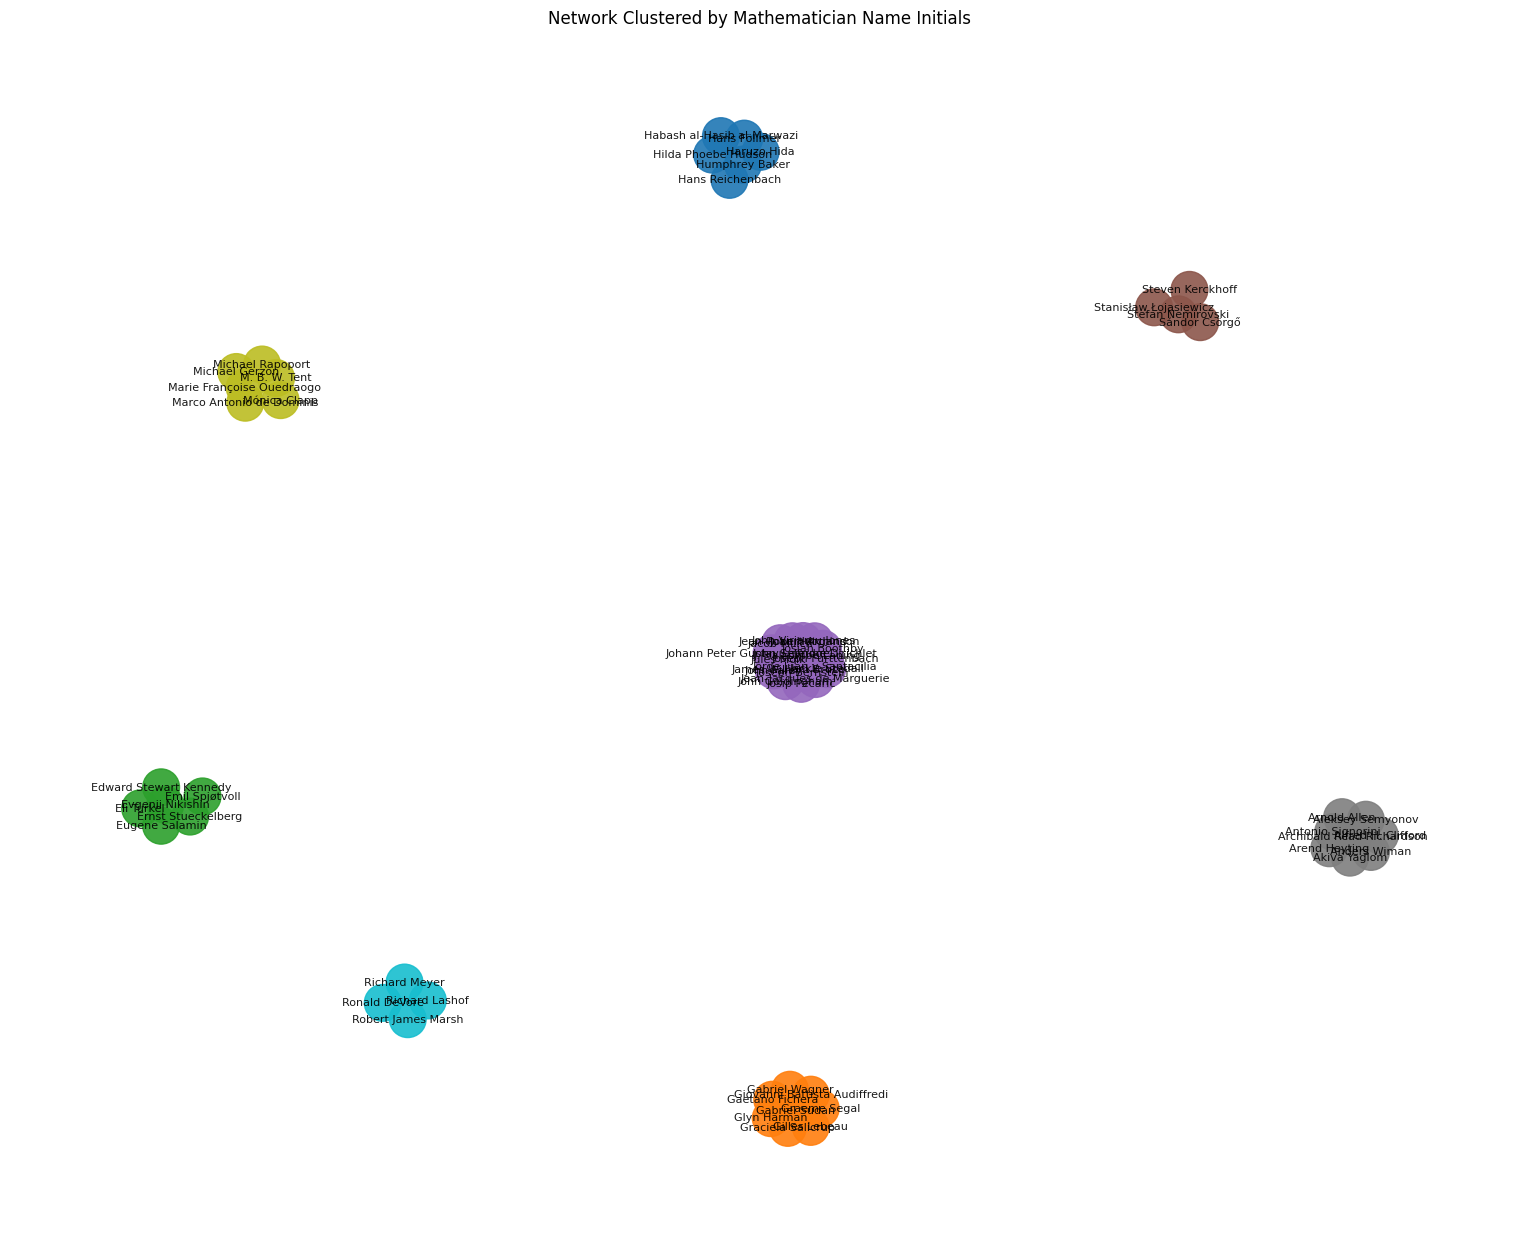

In [6]:
# Extract first initials and common suffixes
df['initial'] = df['tablescraper-selected-row'].str[0]
df['last_letter'] = df['tablescraper-selected-row'].str[-1]

# Filter to keep only a subset of the most common initials to ensure visible clustering
top_initials = df['initial'].value_counts().head(8).index
cluster_df = df[df['initial'].isin(top_initials)].sample(60, random_state=1)

G_granular = nx.Graph()

for _, row in cluster_df.iterrows():
    G_granular.add_node(row['tablescraper-selected-row'], initial=row['initial'])

# Connect nodes if they share the same first initial
nodes_list = list(G_granular.nodes(data=True))
for i in range(len(nodes_list)):
    for j in range(i + 1, len(nodes_list)):
        if nodes_list[i][1]['initial'] == nodes_list[j][1]['initial']:
            G_granular.add_edge(nodes_list[i][0], nodes_list[j][0])

# Visualization
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_granular, k=0.15, seed=42)

unique_initials = cluster_df['initial'].unique()
color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_initials)))
init_color_map = {init: color_palette[i] for i, init in enumerate(unique_initials)}
node_colors = [init_color_map[data['initial']] for _, data in G_granular.nodes(data=True)]

nx.draw(G_granular, pos, with_labels=True, node_color=node_colors,
        node_size=700, font_size=8, edge_color='whitesmoke', alpha=0.9)

plt.title('Network Clustered by Mathematician Name Initials')
plt.show()